In [5]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../kaggle_prediction_library/') 
import preprocess
import feature_engineering
import submission
import validation
from sklearn.model_selection import train_test_split

# from hyperopt import tpe, fmin, Trials
# import hyperopt.hp as hp

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
from sklearn.feature_selection import chi2
from sklearn.metrics import r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import make_pipeline



In [6]:
to_predict_mens = pd.read_csv("to_predict_mens.csv")

### Prepare data 

In [7]:
def prepare_data(to_predict_mens, season):

    to_predict_mens_first_round_train = to_predict_mens[(to_predict_mens["GameRound"] == 1)
                                                        & (to_predict_mens.Season < season)
                                                        & (to_predict_mens.Season >= 2008)
                                                        ].copy()
    
    to_predict_mens_train = to_predict_mens[(to_predict_mens.Season < season)
                                            & (to_predict_mens.Season >= 2008)].copy()

    to_predict_mens_first_round_test = to_predict_mens[(to_predict_mens.Season == season)
                                                    & (to_predict_mens.GameRound == 1)
                                                    & (to_predict_mens.final_odds.notnull())
                                                    ].copy()

    to_predict_mens_other_rounds_test = to_predict_mens[(to_predict_mens.Season == season)
                                                    & (to_predict_mens.GameRound > 1)
                                                    ].copy()
    
    return to_predict_mens_first_round_train, to_predict_mens_train, to_predict_mens_first_round_test, to_predict_mens_other_rounds_test
    


### Statistics Model Training

In [8]:
def train_statistics_model(to_predict_mens_train, statistics_features):

    best_params = {"C": .1}
    model = LogisticRegression(**best_params)
    pipeline = make_pipeline(StandardScaler(), model)
    statistics_model = pipeline.fit(to_predict_mens_train[statistics_features], to_predict_mens_train["Outcome"])

    return statistics_model


### Full Pipeline

In [9]:
SEASON = 2024

statistics_model_full_features = [   't1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    't1_OrdinalRank', 't2_OrdinalRank',
    't1_adj_margin', 't2_adj_margin', 
    ]

statistics_model_first_round_features = ['t1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    't1_OrdinalRank', 't2_OrdinalRank'
    ,]


# get data
to_predict_mens_first_round_train, to_predict_mens_train, to_predict_mens_first_round_test, to_predict_mens_other_rounds_test= prepare_data(to_predict_mens, SEASON)

# train
statistics_model_full = train_statistics_model(to_predict_mens_train, statistics_model_full_features)
statistics_model_first_round = train_statistics_model(to_predict_mens_first_round_train, statistics_model_first_round_features)

# inference
pred_proba = statistics_model_first_round.predict_proba(to_predict_mens_first_round_test[statistics_model_first_round_features].copy())[:,1]
to_predict_mens_first_round_test["Pred"] = pred_proba

pred_proba = statistics_model_full.predict_proba(to_predict_mens_other_rounds_test[statistics_model_full_features].copy())[:,1]
to_predict_mens_other_rounds_test["Pred"] = pred_proba

mens_sub_tmp = pd.concat([to_predict_mens_first_round_test,
        to_predict_mens_other_rounds_test], axis=0)

mens_sub = mens_sub_tmp[["ID", "Pred"]]


### Womens

In [11]:
to_predict_women = pd.read_csv("to_predict_women.csv")

to_predict_women_train = to_predict_women[to_predict_women.Season != 2024] 
to_predict_women_test = to_predict_women[to_predict_women.Season == 2024] 


In [12]:
statistics_features = ['seed_diff', 't1_adj_margin', 't2_adj_margin']
best_params = {"C": .1}
model = LogisticRegression(**best_params)
pipeline = make_pipeline(StandardScaler(), model)
statistics_model = pipeline.fit(to_predict_women_train[statistics_features], to_predict_women_train["Outcome"])
pred_proba = statistics_model.predict_proba(to_predict_women_test[statistics_features].copy())[:,1]
to_predict_women_test["Pred_Baseline"] = pred_proba


/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_79572/889996954.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_predict_women_test["Pred_Baseline"] = pred_proba


In [13]:
SEASON = 2024

features = ['seed_diff', 
    't1_adj_margin', 't2_adj_margin',
    't1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean']

best_params = {"C": .1}

model = LogisticRegression(**best_params)
pipeline = make_pipeline(StandardScaler(), model)

to_predict_mens_train = to_predict_mens[(to_predict_mens.Season < SEASON)
                                            & (to_predict_mens.Season >= 2008)].copy()

statistics_model = pipeline.fit(to_predict_mens_train[features], to_predict_mens_train["Outcome"])
pred_proba = statistics_model.predict_proba(to_predict_women_test[features].copy())[:,1]

to_predict_women_test["Pred_New"] = pred_proba


/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_79572/3365922374.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_predict_women_test["Pred_New"] = pred_proba


In [14]:
to_predict_women_test["Pred"] = (to_predict_women_test["Pred_Baseline"] + to_predict_women_test["Pred_New"]) / 2

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_79572/1750293826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_predict_women_test["Pred"] = (to_predict_women_test["Pred_Baseline"] + to_predict_women_test["Pred_New"]) / 2


In [15]:
womens_sub = to_predict_women_test[["ID", "Pred"]]

In [16]:
final_sub = pd.concat([mens_sub, womens_sub], axis=0)

In [17]:
final_sub.to_csv("traditional_format_sub.csv")

In [18]:
final_sub

,ID,Pred
1319,2024_1112_1253,0.981720
1320,2024_1166_1103,0.902207
1321,2024_1173_1305,0.377529
1322,2024_1182_1140,0.278729
1323,2024_1211_1270,0.921339
...,...,...
1783,2024_3425_3163,0.271958
1784,2024_3261_3234,0.358670
1785,2024_3163_3234,0.561212
1786,2024_3301_3376,0.128575


### Sanity Checks

In [147]:
to_predict_mens_first_round_test.shape


(64, 71)

In [148]:
mens_sub_tmp.columns

Index(['Unnamed: 0', 'type', 'ID', 'Pred', 'Season', 'Team1', 'Team2',
       'Outcome', 'Gender', 'margin', 't1_TeamName', 't1_FirstD1Season',
       't1_LastD1Season', 't2_TeamName', 't2_FirstD1Season', 't2_LastD1Season',
       'final_odds', 'GameRound', 't1_FGM', 't1_FGA', 't1_FGM3', 't1_FGA3',
       't1_OR', 't1_Ast', 't1_TO', 't1_Stl', 't1_PF', 't1_FTA', 't1_FTM',
       't1_PointDiff', 't2_FGM', 't2_FGA', 't2_FGM3', 't2_FGA3', 't2_OR',
       't2_Ast', 't2_TO', 't2_Stl', 't2_PF', 't2_FTA', 't2_FTM',
       't2_PointDiff', 't1_OrdinalRank', 't2_OrdinalRank', 't1_Seed',
       't2_Seed', 'seed_diff', 't1_adj_oe', 't1_adj_de', 't1_adj_margin',
       't2_adj_oe', 't2_adj_de', 't2_adj_margin', 't1_final_rank',
       't2_final_rank', 't1_top8_TO_stdev', 't1_top5_PRPG!_median',
       't1_top3_DR_median', 't1_top5_STL_cv', 't1_top3_Min%_median',
       't1_top8_TS_gini', 't1_top3_USG_gini', 't1_top8_BPM_weighted_mean',
       't2_top8_TO_stdev', 't2_top5_PRPG!_median', 't2_top3_DR_m

In [149]:
mens_sub_tmp[mens_sub_tmp.GameRound == 1][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', "GameRound"]].tail(15)

,Pred,Outcome,t1_TeamName,t2_TeamName,GameRound
2716,0.075026,0,Colgate,Baylor,1
2717,0.223636,0,New Mexico,Clemson,1
2718,0.629267,0,Florida,Colorado,1
2719,0.013424,0,Stetson,Connecticut,1
2720,0.074121,0,Vermont,Duke,1
2721,0.811025,0,St Mary's CA,Grand Canyon,1
2722,0.021255,0,Longwood,Houston,1
2723,0.482819,0,Wisconsin,James Madison,1
2724,0.082702,0,WKU,Marquette,1
2725,0.394904,0,FL Atlantic,Northwestern,1


In [366]:
mens_sub_tmp[mens_sub_tmp.t1_TeamName == "Duke"][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', "GameRound"]].tail(15)

,Pred,Outcome,t1_TeamName,t2_TeamName,GameRound
1339,0.925879,1,Duke,Vermont,1
1361,0.760145,1,Duke,James Madison,2
1370,0.165195,1,Duke,Houston,3
2757,0.713542,0,Duke,NC State,4


In [150]:
brier_score_loss(mens_sub_tmp["Outcome"], mens_sub_tmp["Pred"])

0.16198836126297914

In [349]:
# Round 1 correctness
round1_correctness = mens_sub_tmp[mens_sub_tmp.GameRound == 1][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', 
                                                                "t1_Seed", "t2_Seed", "GameRound"]]
round1_correctness["Outcome_Pred"] = np.where(round1_correctness.Pred > .5, 1, 0 )
round1_correctness["Correct"] = np.where(round1_correctness["Outcome"] == round1_correctness["Outcome_Pred"], 1, 0)
round1_correctness["Correct"].mean()

0.75

In [360]:
round1_correctness[(
   (  (round1_correctness.t1_Seed >= 10) & (round1_correctness.Pred >= .20) )
)
].head(50)

,Pred,Outcome,t1_TeamName,t2_TeamName,t1_Seed,t2_Seed,GameRound,Outcome_Pred,Correct
1321,0.277548,1,Duquesne,BYU,11,6,1,0,0
1327,0.464633,1,NC State,Texas Tech,11,6,1,0,0
1330,0.538631,1,Oregon,South Carolina,11,6,1,1,1
1337,0.370733,1,Colorado,Florida,10,7,1,0,0
1342,0.517181,1,James Madison,Wisconsin,12,5,1,1,1
2701,0.621824,0,Nevada,Dayton,10,7,1,1,0
2714,0.560016,0,Drake,Washington St,10,7,1,1,0
2715,0.228810,0,Col Charleston,Alabama,13,4,1,0,1
2717,0.223636,0,New Mexico,Clemson,11,6,1,0,1
2727,0.248604,0,UAB,San Diego St,12,5,1,0,1


In [293]:
team_name = "Nebraska"

In [327]:
mens_sub_tmp[(mens_sub_tmp.t1_TeamName == "Nebraska")][statistics_model_first_round_features]#.iloc[:,0].tolist()

,t1_top8_BPM_weighted_mean,t2_top8_BPM_weighted_mean,t1_top8_TO_stdev,t2_top8_TO_stdev,t1_top5_PRPG!_median,t2_top5_PRPG!_median,t1_top3_DR_median,t2_top3_DR_median,t1_top5_STL_cv,t2_top5_STL_cv,t1_top3_Min%_median,t2_top3_Min%_median,t1_top8_TS_gini,t2_top8_TS_gini,t1_top3_USG_gini,t2_top3_USG_gini,t1_OrdinalRank,t2_OrdinalRank
2728,4.372878,4.161655,5.122926,3.332792,3.1,3.5,15.6,13.1,0.304446,0.37424,69.1,71.1,0.037684,0.075446,0.018173,0.1801,25.0,13.0


In [341]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_impact(features, values, coefficients, figsize=(10, 6),
                          title="Feature Impact (Value x Coefficient)"):
    """
    Plots the impact of each feature by multiplying its value with its coefficient.

    Parameters:
        features (list of str): Names of the features.
        values (list of float): The values for each feature (e.g., for a given sample).
        coefficients (list of float): The logistic regression coefficients.
        figsize (tuple): Size of the figure.
        title (str): Title for the plot.
    """
    if not (len(features) == len(values) == len(coefficients)):
        raise ValueError("All input lists (features, values, coefficients) must have the same length.")
    
    # Convert to numpy arrays for easy manipulation
    features = np.array(features)
    values = np.array(values)
    coefficients = np.array(coefficients)
    
    # Calculate impact for each feature
    impacts = values * coefficients
    
    # Sort features by the absolute impact in descending order
    sorted_indices = np.argsort(np.abs(impacts))[::-1]
    sorted_features = features[sorted_indices]
    sorted_impacts = impacts[sorted_indices]
    
    # Create colors: blue for positive, red for negative
    colors = ['blue' if impact >= 0 else 'red' for impact in sorted_impacts]
    
    # Plotting
    plt.figure(figsize=figsize)
    bars = plt.barh(sorted_features, sorted_impacts, color=colors)
    plt.xlabel("Impact (Feature Value x Coefficient)")
    plt.title(title)
    plt.axvline(0, color='black', linewidth=1)  # vertical line at zero

    # Annotate each bar with the impact value
    max_impact = np.abs(sorted_impacts).max() if np.abs(sorted_impacts).max() != 0 else 1
    x_offset = 0.02 * max_impact
    for bar in bars:
        width = bar.get_width()
        xpos = width + x_offset if width >= 0 else width - x_offset
        ha = 'left' if width >= 0 else 'right'
        plt.text(xpos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', ha=ha, color='black')
    
    plt.gca().invert_yaxis()  # highest impact at the top
    plt.tight_layout()
    plt.show()




In [342]:
def analyze_first_round_game(t1_team_name):
    scaler = statistics_model_first_round.named_steps['standardscaler']
    scaled_feature_names = ["scaled_" + feature for feature in statistics_model_first_round_features]
    mens_sub_tmp[scaled_feature_names] = scaler.transform(mens_sub_tmp[statistics_model_first_round_features])
    raw_values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name)][statistics_model_first_round_features].transpose().iloc[:,0].tolist()
    values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name)][scaled_feature_names].transpose().iloc[:,0].tolist()
    coef_list = statistics_model_first_round.named_steps['logisticregression'].coef_.tolist()[0]
    df_analysis = pd.DataFrame(list(zip(coef_list, raw_values_list, values_list)), columns = ["model_coef", "raw_feature_value", 
    "feature_value"])
    df_analysis["feature_name"] = statistics_model_first_round_features
    df_analysis["impact"] = df_analysis.model_coef * df_analysis.feature_value
    df_analysis["abs_impact"] = np.abs(df_analysis["impact"])
    df_analysis.sort_values(by="abs_impact", ascending=False)

    net_weighted_values = sum(x * y for x, y in zip(values_list, coef_list))

    print(f"net weighted value: {net_weighted_values}")

    plot_feature_impact(statistics_model_first_round_features, values_list, coef_list)

    return df_analysis[["feature_name", "raw_feature_value", "feature_value",
                        "model_coef", "impact", "abs_impact"]].sort_values(by="abs_impact", ascending=False)

In [362]:
def analyze_non_first_round_game(t1_team_name, t2_team_name):
    scaler = statistics_model_full.named_steps['standardscaler']
    scaled_feature_names = ["scaled_" + feature for feature in statistics_model_full_features]
    mens_sub_tmp[scaled_feature_names] = scaler.transform(mens_sub_tmp[statistics_model_full_features])
    raw_values_list = mens_sub_tmp[
        (mens_sub_tmp.t1_TeamName == t1_team_name) & (mens_sub_tmp.t2_TeamName == t2_team_name)][statistics_model_full_features].transpose().iloc[:,0].tolist()
    values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name) & (mens_sub_tmp.t2_TeamName == t2_team_name)][scaled_feature_names].transpose().iloc[:,0].tolist()
    coef_list = statistics_model_full.named_steps['logisticregression'].coef_.tolist()[0]
    df_analysis = pd.DataFrame(list(zip(coef_list, raw_values_list, values_list)), columns = ["model_coef", "raw_feature_value", 
    "feature_value"])
    df_analysis["feature_name"] = statistics_model_full_features
    df_analysis["impact"] = df_analysis.model_coef * df_analysis.feature_value
    df_analysis["abs_impact"] = np.abs(df_analysis["impact"])
    df_analysis.sort_values(by="abs_impact", ascending=False)

    net_weighted_values = sum(x * y for x, y in zip(values_list, coef_list))

    print(f"net weighted value: {net_weighted_values}")

    plot_feature_impact(statistics_model_full_features, values_list, coef_list)

    return df_analysis[["feature_name", "raw_feature_value", "feature_value",
                        "model_coef", "impact", "abs_impact"]].sort_values(by="abs_impact", ascending=False)

net weighted value: 0.9126483996342238


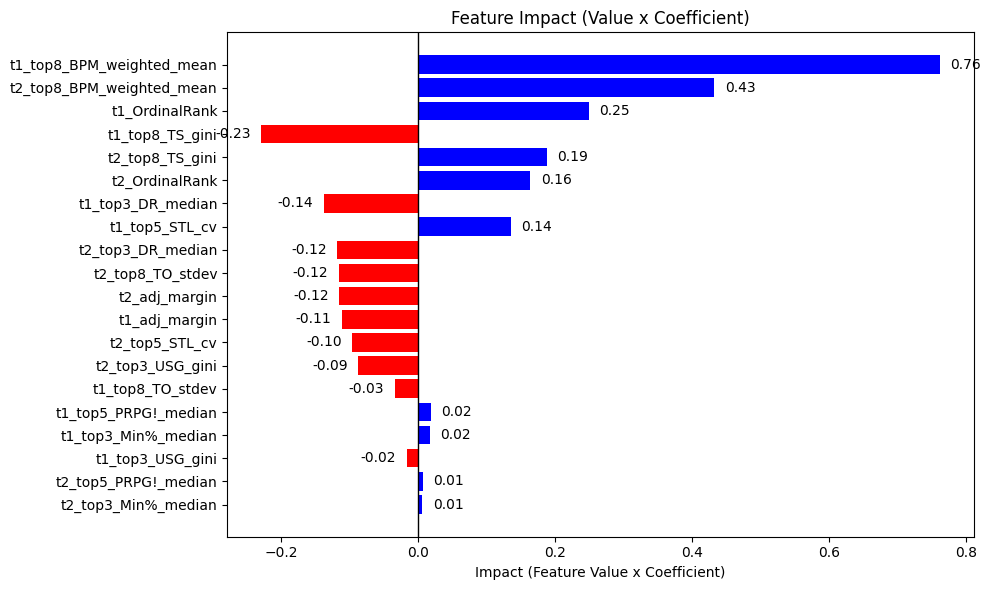

,feature_name,raw_feature_value,feature_value,model_coef,impact,abs_impact
0,t1_top8_BPM_weighted_mean,5.836741,0.774244,0.982932,0.761029,0.761029
1,t2_top8_BPM_weighted_mean,3.456566,-0.439812,-0.982932,0.432305,0.432305
16,t1_OrdinalRank,9.000000,-1.132135,-0.219440,0.248436,0.248436
12,t1_top8_TS_gini,0.020407,-1.863723,0.122877,-0.229008,0.229008
13,t2_top8_TS_gini,0.025883,-1.529943,-0.122877,0.187994,0.187994
17,t2_OrdinalRank,25.000000,0.744315,0.219440,0.163333,0.163333
6,t1_top3_DR_median,15.300000,1.142186,-0.120698,-0.137860,0.137860
8,t1_top5_STL_cv,0.183821,-1.162774,-0.116224,0.135142,0.135142
7,t2_top3_DR_median,9.400000,-0.978755,0.120698,-0.118134,0.118134
3,t2_top8_TO_stdev,3.366007,-0.653918,0.177264,-0.115916,0.115916


In [365]:
analyze_non_first_round_game("Duke", "NC State")